In [3]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
np.random.seed(42)

In [5]:
# ============================================================
# CONFIG — adjust these to scale dataset size
# ============================================================
N_CUSTOMERS    = 8_000          # → ~700K transactions
N_PRODUCTS     = 150
START_DATE     = datetime(2023, 1, 1)
END_DATE       = datetime(2024, 12, 31)
N_DAYS         = (END_DATE - START_DATE).days + 1   # 731 days

print(f"📦 Generating RetailPulse master dataset")
print(f"   Period: {START_DATE.date()} → {END_DATE.date()} ({N_DAYS} days)")
print(f"   Scale:  {N_CUSTOMERS:,} customers × {N_PRODUCTS} products\n")


📦 Generating RetailPulse master dataset
   Period: 2023-01-01 → 2024-12-31 (731 days)
   Scale:  8,000 customers × 150 products



In [6]:
# ============================================================
# 1. PRODUCTS MASTER (150 SKUs across 8 categories)
#    — extends UCI's StockCode + Description with cost/lead time
# ============================================================
print("[1/6] Building products_master ...")

categories = {
    "Home Decor":   {"n": 25, "price_range": (1.5, 25.0),  "lead_time": 7,  "shelf_life": 365},
    "Kitchenware":  {"n": 22, "price_range": (2.0, 45.0),  "lead_time": 10, "shelf_life": 720},
    "Stationery":   {"n": 20, "price_range": (0.5, 15.0),  "lead_time": 5,  "shelf_life": 365},
    "Toys":         {"n": 18, "price_range": (3.0, 50.0),  "lead_time": 14, "shelf_life": 365},
    "Apparel":      {"n": 20, "price_range": (8.0, 80.0),  "lead_time": 21, "shelf_life": 180},
    "Electronics":  {"n": 15, "price_range": (15.0, 250.0),"lead_time": 14, "shelf_life": 720},
    "Beauty":       {"n": 15, "price_range": (4.0, 60.0),  "lead_time": 10, "shelf_life": 540},
    "Food & Bev":   {"n": 15, "price_range": (1.0, 30.0),  "lead_time": 3,  "shelf_life": 90},
}

product_names = {
    "Home Decor":  ["WHITE HANGING HEART T-LIGHT HOLDER","WHITE METAL LANTERN","CREAM CUPID HEARTS COAT HANGER",
                    "GLASS STAR FROSTED T-LIGHT HOLDER","WALL MIRROR ROUND","WOODEN PHOTO FRAME","CERAMIC VASE BLUE",
                    "DREAM CATCHER FEATHER","FAIRY LIGHTS LED","CUSHION COVER VINTAGE","TABLE RUNNER LINEN",
                    "WALL CLOCK ROMAN","DECORATIVE PILLOW","SCENTED CANDLE LAVENDER","FLOWER POT TERRACOTTA",
                    "PHOTO FRAME SILVER","HANGING ORNAMENT GLASS","WALL ART CANVAS","LAMP SHADE FABRIC",
                    "DOOR MAT WELCOME","CURTAIN TIE BACK","WIND CHIME BAMBOO","FIGURINE SET CERAMIC",
                    "BOOKEND PAIR METAL","INCENSE HOLDER WOOD"],
    "Kitchenware": ["SET OF 3 CAKE TINS PANTRY DESIGN","RETROSPOT TEA SET CERAMIC 11 PC","JAM MAKING SET WITH JARS",
                    "IVORY KNITTED MUG COSY","SET 7 BABUSHKA NESTING BOXES","CUTLERY SET STAINLESS","SPICE RACK WOODEN",
                    "WOODEN SPOON SET","CUTTING BOARD BAMBOO","COFFEE GRINDER MANUAL","ELECTRIC KETTLE",
                    "TOASTER 2-SLICE","BLENDER COMPACT","MIXING BOWL CERAMIC","MEASURING CUPS SET",
                    "COOKIE JAR GLASS","BREAD BIN METAL","FRUIT BASKET WIRE","WINE GLASSES SET 6","TEAPOT CERAMIC",
                    "CASSEROLE DISH OVAL","BAKING TRAY NON-STICK"],
    "Stationery":  ["PACK OF 72 RETROSPOT CAKE CASES","NOTEBOOK A5 RULED","FOUNTAIN PEN BLUE","MARKER SET 12 COLORS",
                    "STICKY NOTES PACK","PENCIL CASE CANVAS","DESK ORGANIZER MESH","STAPLER STANDARD",
                    "PAPER CLIPS BOX","FOLDER PACK A4","CALENDAR DESK 2025","DIARY HARDCOVER","HIGHLIGHTERS PACK",
                    "ERASER PACK 10","RULER SET METRIC","SCISSORS OFFICE","TAPE DISPENSER","BINDER CLIPS BOX",
                    "INDEX CARDS PACK","WHITEBOARD A3"],
    "Toys":        ["LOVE BUILDING BLOCK WORD","BABUSHKA BOXES NESTING","POPPY'S PLAYHOUSE BEDROOM",
                    "PLUSH BEAR LARGE","DOLL HOUSE WOODEN","TOY CAR DIE-CAST","PUZZLE 500PC LANDSCAPE",
                    "BOARD GAME FAMILY","ACTION FIGURE HERO","RC HELICOPTER MINI","BUILDING BLOCKS 200PC",
                    "STUFFED ANIMAL DOG","BABY RATTLE WOODEN","PLAY DOUGH SET","COLORING SET CRAYON",
                    "WOODEN TRAIN SET","KITE COLORFUL","FRISBEE BEACH"],
    "Apparel":     ["RED WOOLLY HOTTIE WHITE HEART","KNITTED UNION FLAG HOT WATER BOTTLE","HAND WARMER UNION JACK",
                    "LUNCH BAG SPACEBOY DESIGN","TOTE BAG CANVAS","SCARF KNITTED WOOL","BEANIE HAT WINTER",
                    "GLOVES PAIR LEATHER","SOCKS PACK COTTON","T-SHIRT COTTON WHITE","HOODIE FLEECE","JACKET LIGHT NYLON",
                    "UMBRELLA COMPACT","BACKPACK CASUAL","WALLET LEATHER BIFOLD","BELT LEATHER BLACK",
                    "CAP SUMMER BASEBALL","SHOES CASUAL CANVAS","SLIPPERS HOUSE","PYJAMA SET COTTON"],
    "Electronics": ["BLUETOOTH SPEAKER PORTABLE","HEADPHONES OVER-EAR","USB CABLE TYPE-C","POWER BANK 10000MAH",
                    "PHONE CASE SILICONE","SCREEN PROTECTOR GLASS","WEBCAM HD","KEYBOARD WIRELESS","MOUSE OPTICAL USB",
                    "LED BULB SMART","SMART PLUG WIFI","FITNESS TRACKER","TABLET STAND ALUMINUM","HDMI CABLE 2M",
                    "CHARGER ADAPTER FAST"],
    "Beauty":      ["FACE CREAM MOISTURIZING","LIP BALM NATURAL","NAIL POLISH RED","SHAMPOO HERBAL","CONDITIONER SILK",
                    "BODY LOTION VANILLA","PERFUME 50ML FLORAL","MAKEUP BRUSH SET","HAIR DRYER COMPACT",
                    "FACE MASK PACK 5","SOAP BAR ARTISAN","HAND CREAM SHEA","EYESHADOW PALETTE","LIPSTICK MATTE",
                    "FOUNDATION LIQUID"],
    "Food & Bev":  ["TEA LOOSE LEAF EARL GREY","COFFEE BEANS ARABICA","HONEY JAR ORGANIC","OLIVE OIL EXTRA VIRGIN",
                    "CHOCOLATE BOX ASSORTED","BISCUITS PACK BUTTER","JAM JAR STRAWBERRY","PASTA DRY PENNE",
                    "SAUCE BOTTLE TOMATO","SPICE MIX CURRY","NUT MIX ROASTED","DRIED FRUIT MIX","CEREAL BOX MUESLI",
                    "ENERGY BAR PROTEIN","HERBAL TEA CHAMOMILE"]
}

products = []
sku_id = 10000
for cat, cfg in categories.items():
    for name in product_names[cat][:cfg["n"]]:
        price = round(np.random.uniform(*cfg["price_range"]), 2)
        cost  = round(price * np.random.uniform(0.45, 0.65), 2)
        products.append({
            "StockCode":     f"SKU{sku_id}",
            "Description":   name,
            "Category":      cat,
            "UnitCost":      cost,
            "UnitPrice":     price,
            "LeadTimeDays":  cfg["lead_time"] + np.random.randint(-2, 3),
            "ShelfLifeDays": cfg["shelf_life"],
            "Supplier":      f"SUP{np.random.randint(100, 130)}",
            "MinOrderQty":   int(np.random.choice([10, 20, 50, 100])),
        })
        sku_id += 1

products_df = pd.DataFrame(products)
products_df.to_csv("data/raw/products_master.csv", index=False)
print(f"      ✓ {len(products_df)} products → data/raw/products_master.csv")

# Pareto popularity weights (top 20% drive ~80% of sales — like UCI dataset)
pop_weights = np.random.pareto(1.5, len(products_df)) + 0.1
pop_weights = pop_weights / pop_weights.sum()


[1/6] Building products_master ...
      ✓ 150 products → data/raw/products_master.csv


In [7]:
# ============================================================
# 2. CUSTOMERS MASTER (8,000 customers with demographics)
#    — extends UCI's CustomerID + Country with rich attributes
# ============================================================
print("[2/6] Building customers_master ...")

# Country distribution mirrors UCI Online Retail II (UK ~91%, but slightly diversified)
countries = {"United Kingdom": 0.78, "Germany": 0.05, "France": 0.04, "EIRE": 0.03,
             "Spain": 0.02, "Netherlands": 0.02, "Belgium": 0.015, "Switzerland": 0.015,
             "Portugal": 0.01, "Australia": 0.01, "Norway": 0.01, "USA": 0.005, "Canada": 0.005}
c_names = list(countries.keys())
c_probs = np.array(list(countries.values())); c_probs /= c_probs.sum()

customers = []
for cid in range(N_CUSTOMERS):
    signup = START_DATE + timedelta(days=int(np.random.beta(2, 5) * N_DAYS))
    ctype  = np.random.choice(["loyal","occasional","one_time","at_risk"], p=[0.20, 0.45, 0.25, 0.10])
    customers.append({
        "CustomerID":       12000 + cid,
        "SignupDate":       signup.strftime("%Y-%m-%d"),
        "AgeGroup":         np.random.choice(["18-24","25-34","35-44","45-54","55-64","65+"],
                                              p=[0.12,0.28,0.25,0.18,0.12,0.05]),
        "Gender":           np.random.choice(["F","M","Other"], p=[0.58,0.40,0.02]),
        "Country":          np.random.choice(c_names, p=c_probs),
        "City":             f"City_{np.random.randint(1, 200)}",
        "PreferredChannel": np.random.choice(["Web","Mobile App","In-Store","Phone"], p=[0.55,0.30,0.10,0.05]),
        "LoyaltyTier":      np.random.choice(["Bronze","Silver","Gold","Platinum"], p=[0.50,0.30,0.15,0.05]),
        "EmailOptIn":       int(np.random.choice([1, 0], p=[0.72, 0.28])),
        "CustomerType":     ctype,   # internal label, drives realistic behavior
    })

customers_df = pd.DataFrame(customers)
print(f"      ✓ {len(customers_df)} customers (saved after enrichment)")


[2/6] Building customers_master ...
      ✓ 8000 customers (saved after enrichment)


In [8]:
# ============================================================
# 3. SALES TRANSACTIONS (~700,000 rows — UCI-compatible schema)
#    — includes realistic data quality issues from UCI dataset
# ============================================================
print("[3/6] Building sales_transactions ... (~30 sec)")

type_config = {
    "loyal":      {"n_orders": (25, 60), "active_frac": 1.00, "items": (3, 8)},
    "occasional": {"n_orders": (5, 20),  "active_frac": 0.90, "items": (1, 5)},
    "one_time":   {"n_orders": (1, 3),   "active_frac": 0.30, "items": (1, 3)},
    "at_risk":    {"n_orders": (8, 25),  "active_frac": 0.55, "items": (2, 6)},
}

# Seasonality (Dec spike + weekly pattern, mirrors UCI dataset behavior)
def seasonal_mult(date):
    m = {1:0.85,2:0.80,3:0.95,4:1.00,5:1.05,6:1.00,7:0.95,8:0.90,9:1.00,10:1.10,11:1.30,12:1.55}[date.month]
    d = {0:1.05,1:1.10,2:1.10,3:1.05,4:1.00,5:0.85,6:0.80}[date.weekday()]
    return m * d

transactions = []
invoice_ctr = 600000

for _, cust in customers_df.iterrows():
    cfg = type_config[cust["CustomerType"]]
    signup = datetime.strptime(cust["SignupDate"], "%Y-%m-%d")
    active_until = signup + timedelta(days=int((END_DATE - signup).days * cfg["active_frac"]))
    if active_until <= signup: continue
    
    n_orders = np.random.randint(*cfg["n_orders"])
    order_dates = [signup + timedelta(days=int(np.random.rand()*(active_until-signup).days))
                   for _ in range(n_orders)]
    
    for od in order_dates:
        if np.random.rand() > seasonal_mult(od) * 0.7: continue   # apply seasonality
        invoice = str(invoice_ctr); invoice_ctr += 1
        n_items = np.random.randint(*cfg["items"])
        chosen  = np.random.choice(len(products_df), size=n_items, replace=False, p=pop_weights)
        ts      = od.replace(hour=int(np.clip(np.random.normal(14,3),8,22)), minute=np.random.randint(0,60))
        is_cancel = np.random.rand() < 0.03   # 3% cancellations (UCI: ~2-5%)
        
        for sku_idx in chosen:
            prod = products_df.iloc[sku_idx]
            base_qty = max(1, int(np.random.gamma(2.0, 1.5)))
            if np.random.rand() < 0.015: base_qty = np.random.randint(50, 200)  # B2B bulk
            qty   = -base_qty if is_cancel else base_qty
            price = prod["UnitPrice"] * (0.85 if np.random.rand() < 0.05 else 1.0)  # 5% promo
            transactions.append({
                "Invoice":     ("C"+invoice) if is_cancel else invoice,
                "InvoiceDate": ts.strftime("%Y-%m-%d %H:%M:%S"),
                "CustomerID":  cust["CustomerID"],
                "StockCode":   prod["StockCode"],
                "Description": prod["Description"],
                "Category":    prod["Category"],
                "Quantity":    qty,
                "UnitPrice":   round(price, 2),
                "Country":     cust["Country"],
                "Channel":     cust["PreferredChannel"] if np.random.rand()<0.85 else
                               np.random.choice(["Web","Mobile App","In-Store","Phone"]),
            })

# Inject ~5% guest checkouts (missing CustomerID — like UCI dataset)
n_guest = int(len(transactions) * 0.05)
for i in np.random.choice(len(transactions), n_guest, replace=False):
    transactions[i]["CustomerID"] = ""

sales_df = pd.DataFrame(transactions)
sales_df["TotalPrice"] = (sales_df["Quantity"] * sales_df["UnitPrice"]).round(2)
sales_df.to_csv("data/raw/sales_transactions.csv", index=False)
print(f"      ✓ {len(sales_df):,} transactions → data/raw/sales_transactions.csv")

[3/6] Building sales_transactions ... (~30 sec)
      ✓ 357,645 transactions → data/raw/sales_transactions.csv


In [9]:
# ============================================================
# 4. CHURN LABELS (derived from behavior + 5% noise)
# ============================================================
print("[4/6] Building churn_labels ...")

cutoff = END_DATE - timedelta(days=90)
sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])
last_purchase = (sales_df[sales_df["CustomerID"] != ""]
                 .groupby("CustomerID")["InvoiceDate"].max())

churn_rows = []
for _, c in customers_df.iterrows():
    cid  = c["CustomerID"]
    last = last_purchase.get(cid, pd.NaT)
    if pd.isna(last):
        churned, days_since = 1, 9999
    else:
        days_since = (END_DATE - last).days
        churned    = 1 if days_since > 90 else 0
    if np.random.rand() < 0.05: churned = 1 - churned   # label noise
    churn_rows.append({
        "CustomerID":     cid,
        "DaysSinceLast":  min(days_since, 730),
        "Churned":        churned,
        "ChurnRiskScore": round(min(days_since/180.0, 1.0), 3),
    })

churn_df = pd.DataFrame(churn_rows)
churn_df.to_csv("data/raw/churn_labels.csv", index=False)
churn_rate = churn_df["Churned"].mean()
print(f"      ✓ {len(churn_df)} labels (churn rate: {churn_rate:.1%}) → data/raw/churn_labels.csv")

customers_df.to_csv("data/raw/customers_master.csv", index=False)
print(f"      ✓ {len(customers_df)} customers → data/raw/customers_master.csv")

[4/6] Building churn_labels ...
      ✓ 8000 labels (churn rate: 55.0%) → data/raw/churn_labels.csv
      ✓ 8000 customers → data/raw/customers_master.csv


In [10]:
# ============================================================
# 5. INVENTORY DAILY (~110,000 rows: 150 SKUs × 731 days)
# ============================================================
print("[5/6] Building inventory_daily ... (~10 sec)")

daily_demand = (sales_df[sales_df["Quantity"] > 0]
                .groupby([pd.Grouper(key="InvoiceDate", freq="D"), "StockCode"])["Quantity"]
                .sum().reset_index())
daily_demand.columns = ["Date", "StockCode", "UnitsSold"]

inventory_rows = []
date_range = pd.date_range(START_DATE, END_DATE, freq="D")

for _, prod in products_df.iterrows():
    sku  = prod["StockCode"]
    lead = int(prod["LeadTimeDays"])
    moq  = int(prod["MinOrderQty"])
    sku_demand = daily_demand[daily_demand["StockCode"] == sku].set_index("Date")["UnitsSold"]
    avg_daily  = sku_demand.mean() if len(sku_demand) > 0 else 5
    if pd.isna(avg_daily) or avg_daily == 0: avg_daily = 5
    
    reorder_point = int(avg_daily * lead * 1.5)
    target_stock  = int(avg_daily * (lead + 14))
    stock = target_stock
    pending = []   # (arrival_date, qty)
    
    for d in date_range:
        # Receive orders that arrived
        new_pending = []
        for arr, q in pending:
            if arr <= d: stock += q
            else: new_pending.append((arr, q))
        pending = new_pending
        
        sold = int(sku_demand.get(d, 0))
        actual_sold = min(sold, stock)
        lost_sales  = sold - actual_sold
        stockout    = 1 if lost_sales > 0 else 0
        opening     = stock
        stock       = stock - actual_sold
        
        on_order = sum(q for _, q in pending)
        reorder_qty = 0
        if (stock + on_order) <= reorder_point:
            reorder_qty = max(moq, target_stock - stock - on_order)
            pending.append((d + timedelta(days=lead), reorder_qty))
        
        inventory_rows.append({
            "Date":          d.strftime("%Y-%m-%d"),
            "StockCode":     sku,
            "OpeningStock":  opening,
            "UnitsSold":     actual_sold,
            "LostSales":     lost_sales,
            "ClosingStock":  stock,
            "OnOrder":       sum(q for _, q in pending),
            "ReorderPlaced": reorder_qty,
            "Stockout":      stockout,
            "ReorderPoint":  reorder_point,
            "TargetStock":   target_stock,
        })

inventory_df = pd.DataFrame(inventory_rows)
inventory_df.to_csv("data/raw/inventory_daily.csv", index=False)
print(f"      ✓ {len(inventory_df):,} records → data/raw/inventory_daily.csv")


[5/6] Building inventory_daily ... (~10 sec)
      ✓ 109,650 records → data/raw/inventory_daily.csv


In [11]:
# ============================================================
# 6. UNIFIED MASTER DATASET (joined view for quick analysis)
# ============================================================
print("[6/6] Building master_dataset.csv (joined view) ...")

master = (sales_df
          .merge(products_df[["StockCode","UnitCost","LeadTimeDays","Supplier"]],
                 on="StockCode", how="left")
          .merge(customers_df[["CustomerID","AgeGroup","Gender","LoyaltyTier","SignupDate","CustomerType"]],
                 on="CustomerID", how="left"))
master["Profit"] = ((master["UnitPrice"] - master["UnitCost"]) * master["Quantity"]).round(2)
master.to_csv("data/processed/master_dataset.csv", index=False)
print(f"      ✓ {len(master):,} rows → data/processed/master_dataset.csv")

[6/6] Building master_dataset.csv (joined view) ...
      ✓ 357,645 rows → data/processed/master_dataset.csv


In [12]:
# ============================================================
# FINAL SUMMARY
# ============================================================
total_rows = (len(products_df) + len(customers_df) + len(sales_df)
              + len(churn_df) + len(inventory_df))
revenue = sales_df[sales_df["Quantity"] > 0]["TotalPrice"].sum()

print("\n" + "="*64)
print("  ✅ RETAILPULSE MASTER DATASET — GENERATION COMPLETE")
print("="*64)
print(f"""
📊 FILE INVENTORY:
   data/raw/products_master.csv          {len(products_df):>10,} rows
   data/raw/customers_master.csv         {len(customers_df):>10,} rows
   data/raw/sales_transactions.csv       {len(sales_df):>10,} rows  ← MAIN
   data/raw/churn_labels.csv             {len(churn_df):>10,} rows
   data/raw/inventory_daily.csv          {len(inventory_df):>10,} rows
   data/processed/master_dataset.csv     {len(master):>10,} rows  (joined)
   {'─'*52}
   TOTAL                                 {total_rows:>10,} rows

📈 KEY STATS:
   Date range:        {START_DATE.date()} → {END_DATE.date()}  ({N_DAYS} days)
   Total revenue:     £{revenue:,.2f}
   Active customers:  {sales_df[sales_df['CustomerID']!='']['CustomerID'].nunique():,}
   Unique products:   {sales_df['StockCode'].nunique()}
   Categories:        {sales_df['Category'].nunique()}
   Churn rate:        {churn_rate:.1%}
   Stockout rate:     {inventory_df['Stockout'].mean():.1%}
   Cancellations:     {(sales_df['Quantity']<0).mean():.1%}
   Missing CustIDs:   {(sales_df['CustomerID']=='').mean():.1%} (guest checkouts)

🎯 USE CASE READINESS:
   ✓ F03 Demand Forecasting   → sales_transactions (731 days × 150 SKUs)
   ✓ F02 Customer Segmentation→ customers_master + sales (RFM-ready)
   ✓ F04 Churn Prediction     → churn_labels (binary target + features)
   ✓ F05 Inventory Optimization→ inventory_daily (stock + reorders + lost sales)
""")


  ✅ RETAILPULSE MASTER DATASET — GENERATION COMPLETE

📊 FILE INVENTORY:
   data/raw/products_master.csv                 150 rows
   data/raw/customers_master.csv              8,000 rows
   data/raw/sales_transactions.csv          357,645 rows  ← MAIN
   data/raw/churn_labels.csv                  8,000 rows
   data/raw/inventory_daily.csv             109,650 rows
   data/processed/master_dataset.csv        357,645 rows  (joined)
   ────────────────────────────────────────────────────
   TOTAL                                    483,445 rows

📈 KEY STATS:
   Date range:        2023-01-01 → 2024-12-31  (731 days)
   Total revenue:     £75,130,292.70
   Active customers:  7,603
   Unique products:   150
   Categories:        8
   Churn rate:        55.0%
   Stockout rate:     3.3%
   Cancellations:     3.0%
   Missing CustIDs:   5.0% (guest checkouts)

🎯 USE CASE READINESS:
   ✓ F03 Demand Forecasting   → sales_transactions (731 days × 150 SKUs)
   ✓ F02 Customer Segmentation→ customers_ma

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', 50)

# ===== CELL 2: Load all 5 raw tables =====
sales     = pd.read_csv("data/raw/sales_transactions.csv", parse_dates=['InvoiceDate'])
customers = pd.read_csv("data/raw/customers_master.csv", parse_dates=['SignupDate'])
products  = pd.read_csv("data/raw/products_master.csv")
churn     = pd.read_csv("data/raw/churn_labels.csv")
inventory = pd.read_csv("data/raw/inventory_daily.csv", parse_dates=['Date'])

print(f"Sales:     {sales.shape}      cols: {list(sales.columns)}")
print(f"Customers: {customers.shape}  cols: {list(customers.columns)}")
print(f"Products:  {products.shape}   cols: {list(products.columns)}")
print(f"Churn:     {churn.shape}      cols: {list(churn.columns)}")
print(f"Inventory: {inventory.shape}  cols: {list(inventory.columns)}")

Sales:     (357645, 11)      cols: ['Invoice', 'InvoiceDate', 'CustomerID', 'StockCode', 'Description', 'Category', 'Quantity', 'UnitPrice', 'Country', 'Channel', 'TotalPrice']
Customers: (8000, 10)  cols: ['CustomerID', 'SignupDate', 'AgeGroup', 'Gender', 'Country', 'City', 'PreferredChannel', 'LoyaltyTier', 'EmailOptIn', 'CustomerType']
Products:  (150, 9)   cols: ['StockCode', 'Description', 'Category', 'UnitCost', 'UnitPrice', 'LeadTimeDays', 'ShelfLifeDays', 'Supplier', 'MinOrderQty']
Churn:     (8000, 4)      cols: ['CustomerID', 'DaysSinceLast', 'Churned', 'ChurnRiskScore']
Inventory: (109650, 11)  cols: ['Date', 'StockCode', 'OpeningStock', 'UnitsSold', 'LostSales', 'ClosingStock', 'OnOrder', 'ReorderPlaced', 'Stockout', 'ReorderPoint', 'TargetStock']


In [14]:
# ===== CELL 3: Distribution analysis =====
print("="*60)
print("SALES TRANSACTIONS — Numeric distributions")
print("="*60)
print(sales[['Quantity', 'UnitPrice', 'TotalPrice']].describe())

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
for name, df in [("sales", sales), ("customers", customers),
                 ("products", products), ("churn", churn), ("inventory", inventory)]:
    miss = df.isnull().sum().sum() + (df == "").sum().sum() if "object" in df.dtypes.values else df.isnull().sum().sum()
    print(f"{name:12s}: {miss:>6} missing/empty")

# Specifically check sales for missing CustomerID
guest_pct = (sales['CustomerID'].astype(str).isin(['', 'nan'])).mean() * 100
print(f"\nGuest checkouts (no CustomerID): {guest_pct:.1f}%")

# Cancellation rate
cancel_pct = sales['Invoice'].astype(str).str.startswith('C').mean() * 100
print(f"Cancellation rate: {cancel_pct:.1f}%")

SALES TRANSACTIONS — Numeric distributions
            Quantity      UnitPrice     TotalPrice
count  357645.000000  357645.000000  357645.000000
mean        4.204502      48.451590     203.108559
std        15.936343      64.004877    1318.574668
min      -199.000000       1.460000  -44187.940000
25%         1.000000      13.640000      19.290000
50%         2.000000      25.110000      47.450000
75%         4.000000      47.450000     141.240000
max       199.000000     246.860000   49125.140000

MISSING VALUES
sales       :  17882 missing/empty
customers   :      0 missing/empty
products    :      0 missing/empty
churn       :      0 missing/empty
inventory   :      0 missing/empty

Guest checkouts (no CustomerID): 5.0%
Cancellation rate: 3.0%


In [16]:
import os
os.makedirs("reports", exist_ok=True)

plt.savefig('reports/day1_distributions.png', dpi=120, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

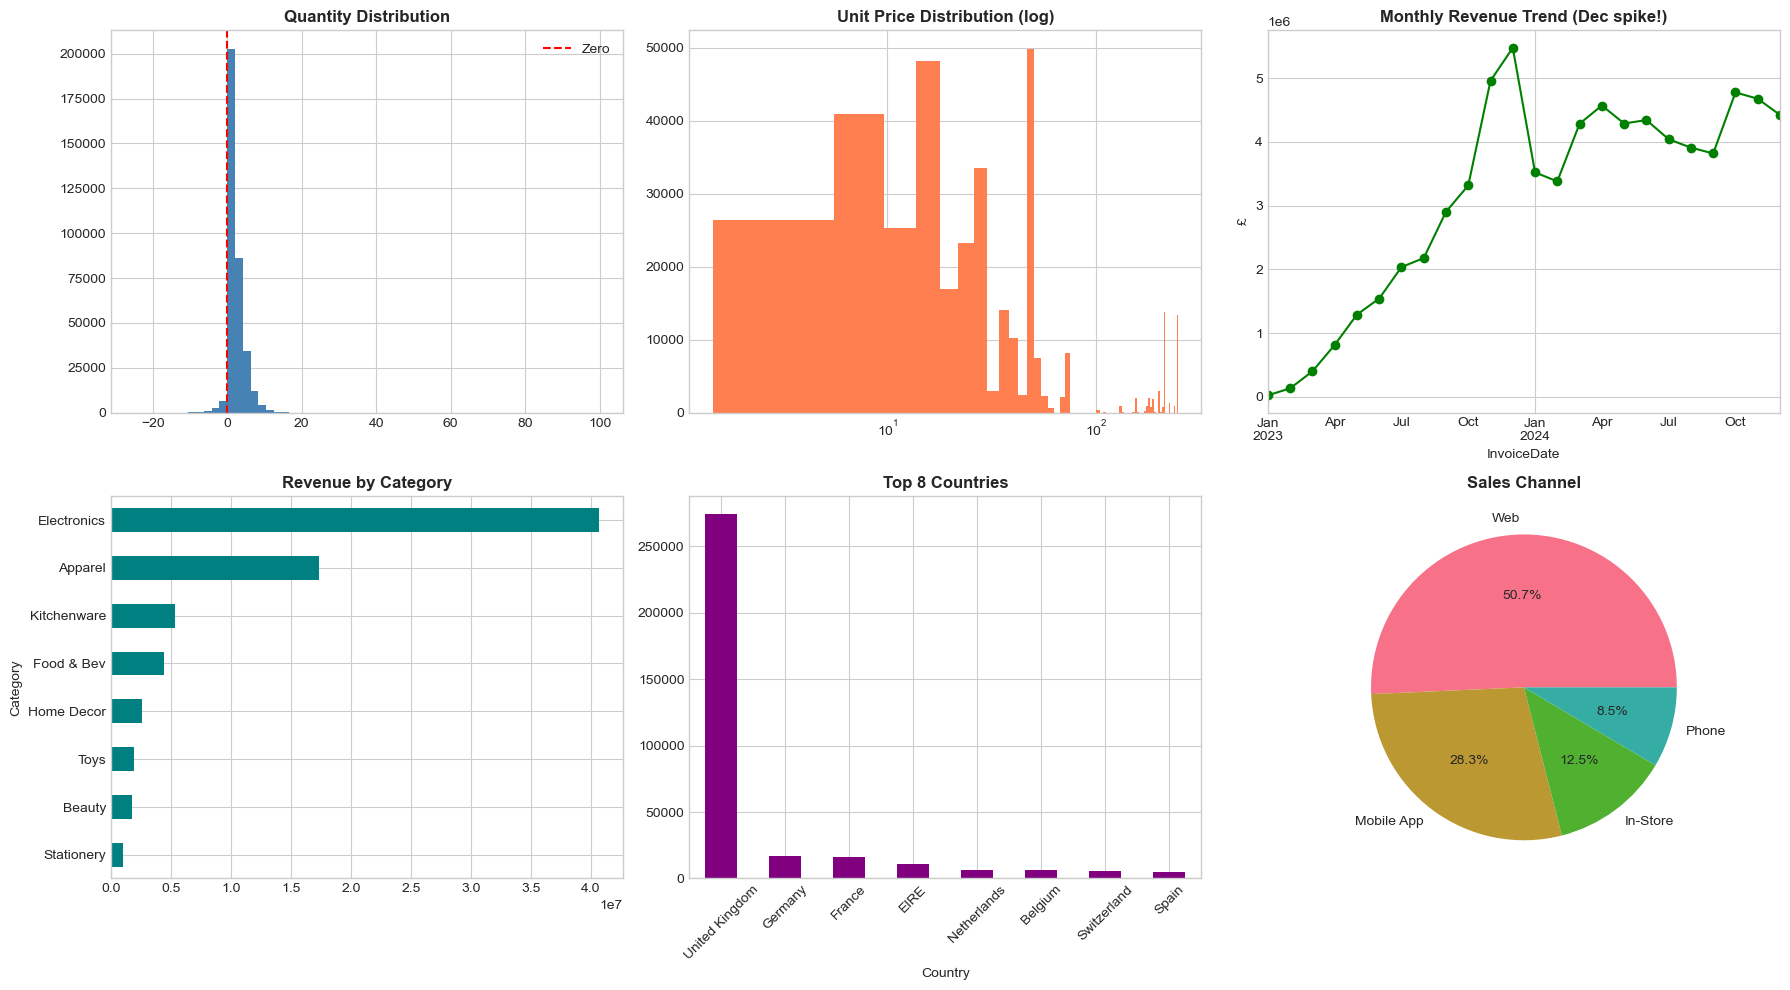

In [17]:
# ===== CELL 4: Visualization — 6-panel EDA dashboard =====
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Quantity distribution (clipped)
sales[sales['Quantity'].between(-50, 100)]['Quantity'].hist(bins=60, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Quantity Distribution', fontweight='bold')
axes[0,0].axvline(0, color='red', linestyle='--', label='Zero')
axes[0,0].legend()

# 2. UnitPrice (log scale)
sales[sales['UnitPrice'] > 0]['UnitPrice'].hist(bins=60, ax=axes[0,1], color='coral')
axes[0,1].set_xscale('log')
axes[0,1].set_title('Unit Price Distribution (log)', fontweight='bold')

# 3. Monthly revenue trend
monthly = (sales[sales['Quantity']>0]
           .groupby(pd.Grouper(key='InvoiceDate', freq='M'))['TotalPrice'].sum())
monthly.plot(ax=axes[0,2], color='green', marker='o')
axes[0,2].set_title('Monthly Revenue Trend (Dec spike!)', fontweight='bold')
axes[0,2].set_ylabel('£')

# 4. Top categories
sales[sales['Quantity']>0].groupby('Category')['TotalPrice'].sum().sort_values().plot(
    kind='barh', ax=axes[1,0], color='teal')
axes[1,0].set_title('Revenue by Category', fontweight='bold')

# 5. Country distribution (top 8)
sales['Country'].value_counts().head(8).plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Top 8 Countries', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Channel split
sales['Channel'].value_counts().plot(kind='pie', ax=axes[1,2], autopct='%1.1f%%')
axes[1,2].set_title('Sales Channel', fontweight='bold')
axes[1,2].set_ylabel('')

plt.tight_layout()
plt.savefig('reports/day1_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

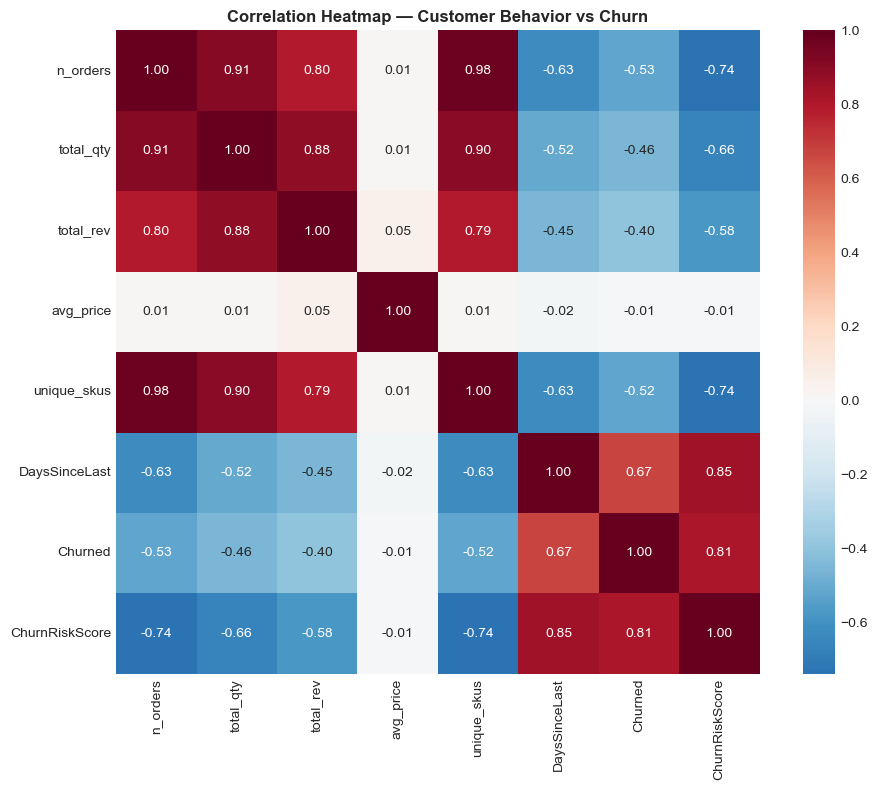

In [18]:
# ===== CELL 5: Correlation heatmap =====
# Build a customer-level analytical view
cust_view = (sales[sales['Quantity']>0]
             .groupby('CustomerID')
             .agg(n_orders=('Invoice','nunique'),
                  total_qty=('Quantity','sum'),
                  total_rev=('TotalPrice','sum'),
                  avg_price=('UnitPrice','mean'),
                  unique_skus=('StockCode','nunique'))
             .reset_index())
cust_view['CustomerID'] = cust_view['CustomerID'].astype(float).astype(int).astype(str)
churn['CustomerID'] = churn['CustomerID'].astype(float).astype(int).astype(str)



merged = cust_view.merge(churn, on='CustomerID')
corr = merged[['n_orders','total_qty','total_rev','avg_price','unique_skus',
               'DaysSinceLast','Churned','ChurnRiskScore']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True)
plt.title('Correlation Heatmap — Customer Behavior vs Churn', fontweight='bold')
plt.tight_layout()
plt.savefig('reports/day1_correlation.png', dpi=120)
plt.show()